# Import & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/processed/combined_additional_features_new.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
print(f"\nKolom tersedia ({len(df.columns)}):")
print(df.columns.tolist())

Shape: (204, 31)
Date range: 2009-01-01 00:00:00 → 2025-12-01 00:00:00

Kolom tersedia (31):
['date', 'gdelt_crisis_score', 'avg_tone', 'risk_ratio', 'trend_composite', 'trend_risk_score', 'trend_drop_flag', 'economic_index', 'economic_risk_score', 'eq_count', 'eq_max_magnitude', 'eq_seismic_energy', 'eq_risk_score', 'wx_precip_sum', 'wx_humidity_mean', 'bmkg_max_magnitude_30d', 'bmkg_seismic_energy', 'earthquake_count', 'earthquake_count_m5_plus', 'pvmbg_volcano_status', 'volcano_status_agung', 'volcano_status_batur', 'bmkg_extreme_weather_days', 'weather_max_rain', 'weather_max_wind_speed', 'weather_max_wind_gust', 'weather_max_temperature', 'eq_count_log', 'eq_m5plus_log', 'rain_log', 'disaster_risk_score']


# Eksplorasi 4 Risk Scores Utama

=== Distribusi Risk Scores ===
       gdelt_crisis_score  economic_risk_score  disaster_risk_score  \
count            204.0000             204.0000             204.0000   
mean               0.3102               0.2837               0.1419   
std                0.1515               0.2152               0.1023   
min                0.0141               0.0000               0.0131   
25%                0.1774               0.2024               0.0463   
50%                0.3620               0.2264               0.1326   
75%                0.4329               0.3516               0.1972   
max                0.6754               1.0000               0.5241   

       trend_risk_score  
count          204.0000  
mean             0.4711  
std              0.2427  
min              0.0000  
25%              0.2997  
50%              0.4473  
75%              0.6350  
max              1.0000  


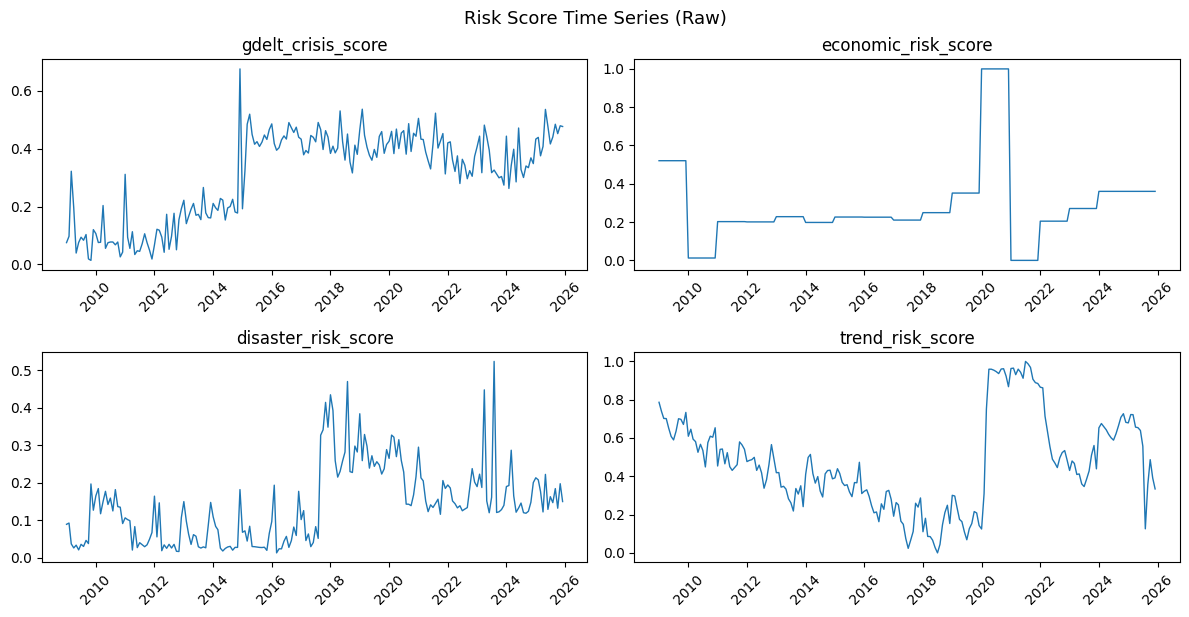

In [2]:
risk_cols = ['gdelt_crisis_score', 'economic_risk_score', 
             'disaster_risk_score', 'trend_risk_score']

print("=== Distribusi Risk Scores ===")
print(df[risk_cols].describe().round(4))

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, col in zip(axes.flatten(), risk_cols):
    ax.plot(df['date'], df[col], linewidth=1)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.suptitle('Risk Score Time Series (Raw)', y=1.02, fontsize=13)
plt.show()

# Rolling Features (MA3 + Slope 3m)

In [3]:
# Kolom target untuk rolling features
rolling_targets = ['gdelt_crisis_score', 'disaster_risk_score', 'economic_risk_score']

def rolling_slope(series, window=3):
    """Hitung slope linear regression rolling window."""
    slopes = [np.nan] * len(series)
    for i in range(window - 1, len(series)):
        y = series[i - window + 1 : i + 1].values
        x = np.arange(window)
        slope, _, _, _, _ = stats.linregress(x, y)
        slopes[i] = slope
    return slopes

for col in rolling_targets:
    # Moving average 3 bulan
    df[f'{col}_ma3'] = df[col].rolling(window=3, min_periods=1).mean()
    
    # Slope 3 bulan (trend direction)
    df[f'{col}_slope3m'] = rolling_slope(df[col], window=3)

print("Rolling features dibuat:")
new_rolling = [c for c in df.columns if '_ma3' in c or '_slope3m' in c]
print(new_rolling)
print(f"\nNull dari slope (wajar di awal):")
print(df[new_rolling].isnull().sum())

Rolling features dibuat:
['gdelt_crisis_score_ma3', 'gdelt_crisis_score_slope3m', 'disaster_risk_score_ma3', 'disaster_risk_score_slope3m', 'economic_risk_score_ma3', 'economic_risk_score_slope3m']

Null dari slope (wajar di awal):
gdelt_crisis_score_ma3         0
gdelt_crisis_score_slope3m     2
disaster_risk_score_ma3        0
disaster_risk_score_slope3m    2
economic_risk_score_ma3        0
economic_risk_score_slope3m    2
dtype: int64


# Z-score Anomali (Rolling Window 12 Bulan)

In [4]:
# Rolling z-score: seberapa jauh nilai bulan ini dari mean 12 bulan terakhir
zscore_targets = ['gdelt_crisis_score', 'disaster_risk_score']

def rolling_zscore(series, window=12):
    roll_mean = series.rolling(window=window, min_periods=6).mean()
    roll_std  = series.rolling(window=window, min_periods=6).std()
    z = (series - roll_mean) / roll_std.replace(0, np.nan)
    return z

for col in zscore_targets:
    df[f'{col}_zscore'] = rolling_zscore(df[col], window=12)

print("Z-score features dibuat:")
zscore_cols = [c for c in df.columns if '_zscore' in c]
print(zscore_cols)
print()
print(df[zscore_cols].describe().round(3))

Z-score features dibuat:
['gdelt_crisis_score_zscore', 'disaster_risk_score_zscore']

       gdelt_crisis_score_zscore  disaster_risk_score_zscore
count                    199.000                     199.000
mean                       0.102                      -0.021
std                        0.965                       1.006
min                       -1.755                      -2.332
25%                       -0.593                      -0.718
50%                        0.002                      -0.304
75%                        0.751                       0.556
max                        3.137                       2.856


# Composite External Risk Score

=== Composite Features ===
       external_risk_avg  external_risk_max  external_risk_range
count           204.0000           204.0000             204.0000
mean              0.3017             0.5500               0.4518
std               0.1072             0.1910               0.1962
min               0.1569             0.2283               0.0937
25%               0.2221             0.4240               0.3142
50%               0.2809             0.4822               0.4078
75%               0.3572             0.6436               0.5461
max               0.6742             1.0000               1.0000


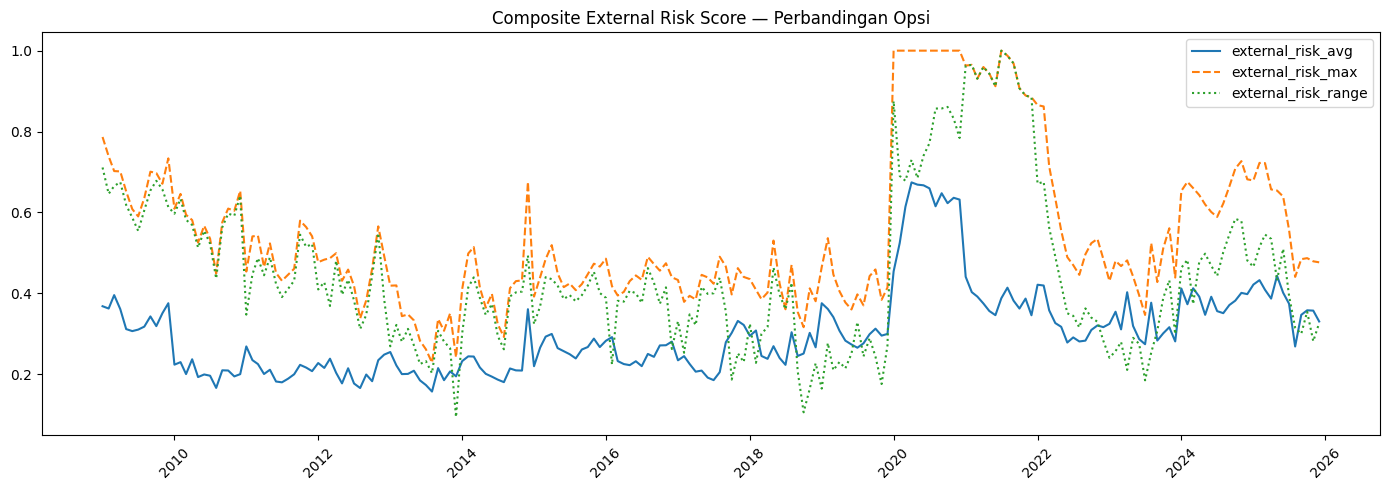

In [5]:
risk_components = [
    'gdelt_crisis_score',
    'economic_risk_score',
    'trend_risk_score',
    'disaster_risk_score',
]

# Pastikan semua komponen tersedia
assert all(c in df.columns for c in risk_components), \
    f"Kolom hilang: {[c for c in risk_components if c not in df.columns]}"

# A: Equal weight average — sinyal rata-rata semua dimensi
df['external_risk_avg'] = df[risk_components].mean(axis=1)

# C: Max of components — shock detector, satu dimensi ekstrem sudah cukup
df['external_risk_max'] = df[risk_components].max(axis=1)

# Bonus: Range spread — divergensi antar komponen
# Tinggi → satu komponen meledak, lainnya normal (pola anomali unik)
df['external_risk_range'] = (
    df[risk_components].max(axis=1) - df[risk_components].min(axis=1)
)

print("=== Composite Features ===")
composite_cols = ['external_risk_avg', 'external_risk_max', 'external_risk_range']
print(df[composite_cols].describe().round(4))

# Visualisasi perbandingan
fig, ax = plt.subplots(figsize=(14, 5))
for col, style in zip(composite_cols, ['-', '--', ':']):
    ax.plot(df['date'], df[col], linestyle=style, label=col, linewidth=1.5)
ax.set_title('Composite External Risk Score — Perbandingan Opsi')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Validasi & Korelasi

Total fitur baru: 11
Total kolom setelah FE: 42

Null per fitur baru:
gdelt_crisis_score_slope3m     2
disaster_risk_score_slope3m    2
economic_risk_score_slope3m    2
gdelt_crisis_score_zscore      5
disaster_risk_score_zscore     5
dtype: int64

=== Korelasi Antar Risk Components ===


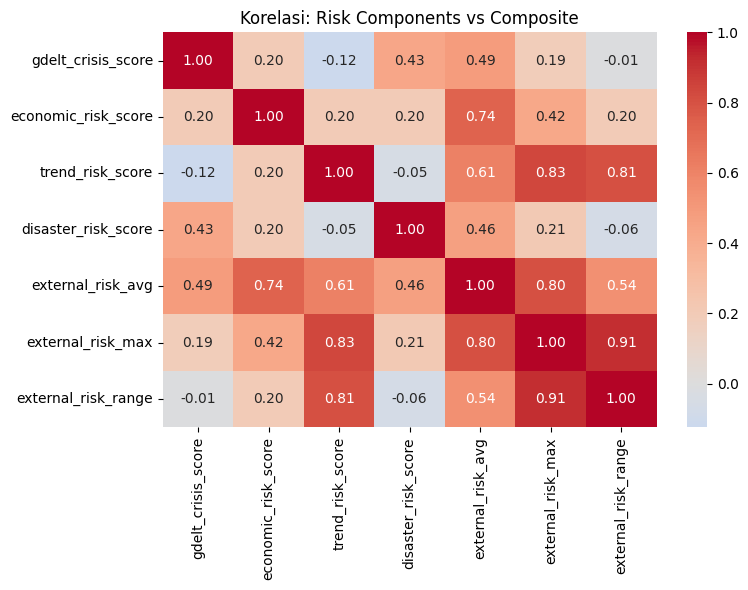

In [6]:
# Semua fitur baru
new_features = (
    [f'{c}_ma3' for c in rolling_targets] +
    [f'{c}_slope3m' for c in rolling_targets] +
    [f'{c}_zscore' for c in zscore_targets] +
    ['external_risk_avg', 'external_risk_max', 'external_risk_range']
)

print(f"Total fitur baru: {len(new_features)}")
print(f"Total kolom setelah FE: {len(df.columns)}")
print()

# Cek null
null_check = df[new_features].isnull().sum()
print("Null per fitur baru:")
print(null_check[null_check > 0])  # hanya tampil yang ada null-nya

# Korelasi antar composite
print("\n=== Korelasi Antar Risk Components ===")
corr_df = df[risk_components + composite_cols].corr().round(3)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Korelasi: Risk Components vs Composite')
plt.tight_layout()
plt.show()

# Export

In [7]:
# Kolom yang memang dibutuhkan untuk model
cols_to_keep = (
    ['date'] +
    risk_components +          # 4 skor utama (sudah engineered dari NB sebelumnya)
    new_features               # 12 fitur baru yang baru kita buat
)

df_export = df[cols_to_keep]
df_export.to_csv('../data/processed/combined_additional_features_engineered_new.csv', index=False)

print(f"Kolom yang disimpan: {len(df_export.columns)}")
print(df_export.columns.tolist())

Kolom yang disimpan: 16
['date', 'gdelt_crisis_score', 'economic_risk_score', 'trend_risk_score', 'disaster_risk_score', 'gdelt_crisis_score_ma3', 'disaster_risk_score_ma3', 'economic_risk_score_ma3', 'gdelt_crisis_score_slope3m', 'disaster_risk_score_slope3m', 'economic_risk_score_slope3m', 'gdelt_crisis_score_zscore', 'disaster_risk_score_zscore', 'external_risk_avg', 'external_risk_max', 'external_risk_range']


In [8]:
import pandas as pd

df = pd.read_csv("../data/final/predictions_final.csv")

for m in ["2011-07","2020-03"]:
    row = df[df["month"] == m].iloc[0]

    print("\n",m)

    print("physical =",row["physical_risk_score"])
    print("media    =",row["media_risk_score"])
    print("tourist  =",row["tourist_perception_score"])
    print("external =",row["external_risk_score"])


 2011-07
physical = 0.0402751279810184
media    = 0.0453158919528217
tourist  = 0.7114734928954047
external = 0.1797365990053117

 2020-03
physical = 0.3218912394772672
media    = 0.3829339711130832
tourist  = 0.8076266370189022
external = 0.6139355250010408
